# Gold Sentiment Dataset — Exploratory Data Analysis

This is a quick, baseline exploration of the dataset used in `src/training.py`. It covers:

- Class distribution and imbalance
- Headline length by class
- Past vs Future information breakdown (a key data-quality gap in the original training code)
- Sample headlines per class
- Top adjectives per class (manual NLP hypothesis-testing)

Helper functions (`load_data`, `summarise_*`, `show_sample_headlines`) live in `src/eda.py`.
Visualisation is done inline here.


In [2]:
%matplotlib inline
import sys

sys.path.insert(0, 'src')

import nltk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from eda import (
    CLASSES,
    COLORS,
    load_data,
    show_sample_headlines,
    summarise_classes,
    summarise_headline_lengths,
    summarise_past_future,
)

data = load_data(csv_path='./data/gold-dataset-sinha-khandait.csv')
data['word_count'] = data['News'].str.split().str.len()
n_classes = data['Price Sentiment'].nunique()
print(f'Loaded {len(data):,} rows, {n_classes} classes.')

Loaded 10,570 rows, 4 classes.


## 1. Class Distribution

As a first step, we check how evenly the four sentiment classes are represented.
Heavy imbalance means a naive classifier that always predicts the majority class can
score deceptively well on accuracy. This is likely one reason Ethan chose to use weighted F1 as the primary metric, rather than accuracy.


=== Class Distribution ===
  positive    4412  (41.7%)
  negative    3814  (36.1%)
  none        1968  (18.6%)
  neutral      376  (3.6%)
  TOTAL      10570



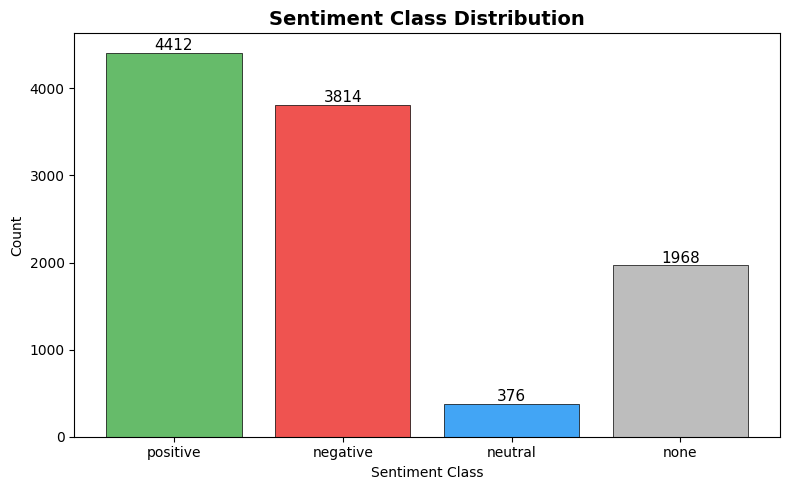

In [3]:
summarise_classes(data=data)

counts = data["Price Sentiment"].value_counts().reindex(CLASSES)
bar_colors = [COLORS[cls] for cls in CLASSES]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x=CLASSES,
    height=counts.values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title(
    label="Sentiment Class Distribution",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel(xlabel="Sentiment Class")
ax.set_ylabel(ylabel="Count")

for i, count in enumerate(counts.values):
    ax.text(x=i, y=count + 30, s=str(count), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 2. Headline Length by Class

Hypothesis: Some sentiment classes may skew towards longer or shorter headlines. This could happen, for instance, if bullish, forward-looking headlines use language that is more qualified, hence more verbose, than terse factual reports of price falls. We thus consider per-class word-count distributions. This will also help us check whether length is a confounding feature the model might exploit, rather than learning genuine sentiment signals. Each histogram below shows the full distribution rather than just summary statistics, making outliers and multi-modal shapes visible.


=== Headline Word Count by Class ===
  positive    min=3, max=20, mean=8.9, median=9
  negative    min=1, max=19, mean=8.9, median=9
  neutral     min=3, max=16, mean=8.4, median=8
  none        min=2, max=21, mean=9.1, median=9



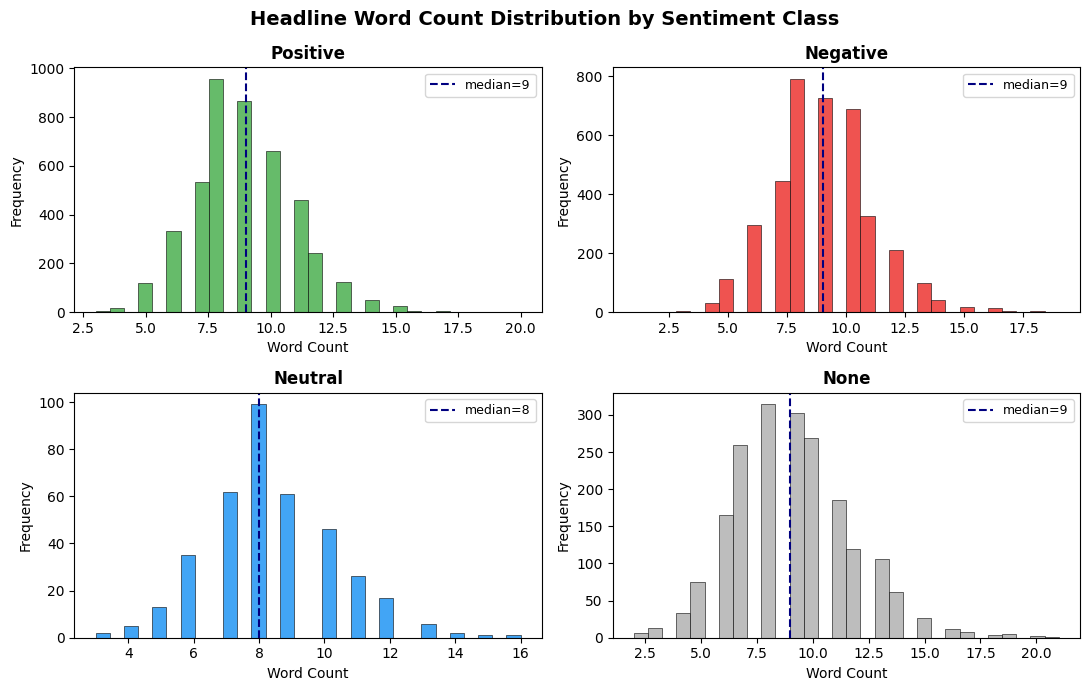

In [4]:
summarise_headline_lengths(data=data)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 7), sharey=False)

for ax, cls in zip(axes.flat, CLASSES):
    wc = data[data["Price Sentiment"] == cls]["word_count"]

    ax.hist(
        x=wc,
        bins=30,
        color=COLORS[cls],
        edgecolor="black",
        linewidth=0.4,
    )

    ax.axvline(
        x=wc.median(),
        color="navy",
        linestyle="--",
        linewidth=1.5,
        label=f"median={wc.median():.0f}",
    )

    ax.set_title(label=cls.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel="Word Count")
    ax.set_ylabel(ylabel="Frequency")
    ax.legend(fontsize=9)

fig.suptitle(
    t="Headline Word Count Distribution by Sentiment Class",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## 3. Past vs Future Information

The dataset flags each headline as reporting a historical price move (`Past Information=1`)
or making a forward-looking prediction (`Future Information=1`). These are qualitatively
different types of text: a retrospective report _confirms_ what happened, whereas a
prediction expresses _expectation_ or _uncertainty_. If one sentiment class is dominated
by past-tense reports and another by predictions, the model may learn writing style
rather than genuine sentiment. The training code does not filter or weight by this flag;
the chart below shows whether that matters.


=== Past vs Future Information Breakdown by Class ===
  Past=1 -> headline reports a historical price move.
  Future=1 -> headline makes a forward-looking prediction.

  positive (n=4412):
    Past only:    4353  (98.7%)
    Future only:    59  (1.3%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  negative (n=3814):
    Past only:    3775  (99.0%)
    Future only:    39  (1.0%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  neutral (n=376):
    Past only:     327  (87.0%)
    Future only:    49  (13.0%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  none (n=1968):
    Past only:    1796  (91.3%)
    Future only:   171  (8.7%)
    Both:            1  (0.1%)
    Neither:         0  (0.0%)



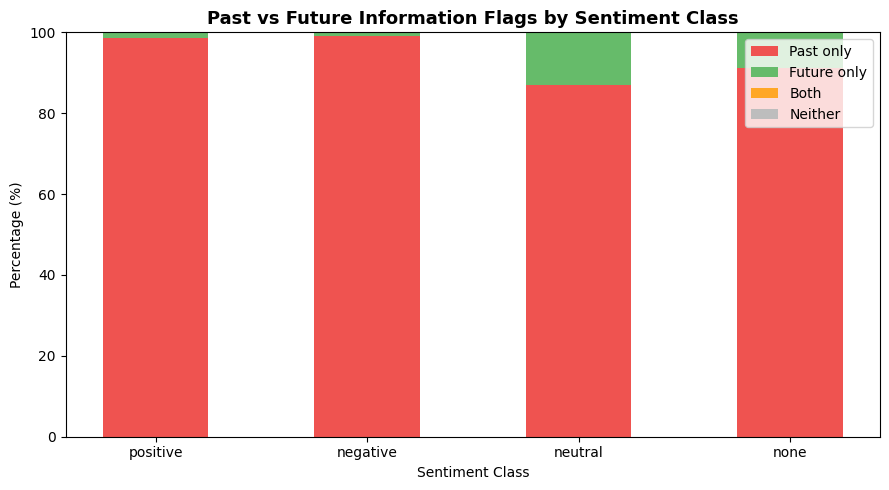

In [5]:
summarise_past_future(data=data)

past_only_pcts = []
future_only_pcts = []
both_pcts = []
neither_pcts = []

for cls in CLASSES:
    subset = data[data["Price Sentiment"] == cls]
    n = len(subset)
    n_past = int(subset["Past Information"].sum())
    n_future = int(subset["Future Information"].sum())
    n_both = int(
        ((subset["Past Information"] == 1) & (subset["Future Information"] == 1)).sum()
    )

    n_neither = int(
        ((subset["Past Information"] == 0) & (subset["Future Information"] == 0)).sum()
    )

    past_only_pcts.append(100 * (n_past - n_both) / n)
    future_only_pcts.append(100 * (n_future - n_both) / n)
    both_pcts.append(100 * n_both / n)
    neither_pcts.append(100 * n_neither / n)

x_pos = np.arange(len(CLASSES))
width = 0.5
bottom_future = np.array(past_only_pcts)
bottom_both = bottom_future + np.array(future_only_pcts)
bottom_neither = bottom_both + np.array(both_pcts)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x=x_pos,
    height=past_only_pcts,
    width=width,
    label="Past only",
    color="#ef5350",
)

ax.bar(
    x=x_pos,
    height=future_only_pcts,
    width=width,
    bottom=bottom_future,
    label="Future only",
    color="#66bb6a",
)

ax.bar(
    x=x_pos,
    height=both_pcts,
    width=width,
    bottom=bottom_both,
    label="Both",
    color="#ffa726",
)

ax.bar(
    x=x_pos,
    height=neither_pcts,
    width=width,
    bottom=bottom_neither,
    label="Neither",
    color="#bdbdbd",
)

ax.set_xticks(ticks=x_pos)
ax.set_xticklabels(labels=CLASSES)

ax.set_title(
    label="Past vs Future Information Flags by Sentiment Class",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel(xlabel="Sentiment Class")
ax.set_ylabel(ylabel="Percentage (%)")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Sample Headlines per Class

Before any modelling, it is worth eyeballing a handful of raw headlines to build
intuition about the task. This sanity-check often surfaces labelling inconsistencies,
near-duplicate headlines, or ambiguous cases that summary statistics will not reveal.


In [6]:
show_sample_headlines(data=data, n=3)

=== 3 Sample Headlines per Class ===

  POSITIVE:
    - gold not done yet, expert says sept to bring all-time high
    - gold futures close higher as the dollar weakens
    - Gold gains as a investors seek safe harbor from geopolitical woes

  NEGATIVE:
    - Gold futures trade lower ahead of Comex settlement
    - april gold falls $10.60, or 0.8%, to settle at $1,337.30/oz
    - gold falls on dollar strength, lower stocks

  NEUTRAL:
    - Gold prices little changed after housing, import data
    - gold, silver may trade on rangebound note:angel commodities
    - gold futures hover near 4-year lows on stronger dollar

  NONE:
    - MCX gold may touch Rs 28,500 per 10 gm
    - gold jewellery sales expected to double this akshaya tritiya
    - gold, silver and oil markets hope for better year



## 5. Top Adjectives per Class

A useful manual hypothesis to test is: _do different sentiment classes use systematically
different descriptive language?_ If positive headlines cluster around words like
"higher" and "strong" while negative ones use "lower" and "weak", that is evidence the
task is learnable from surface lexical features alone — and it also tells us something
about what the model is likely learning.

We use NLTK's part-of-speech tagger to extract adjectives (Penn Treebank tags `JJ`,
`JJR`, `JJS` — base, comparative, and superlative forms) from every headline in each
class, then rank them by frequency. The resulting table is a fast, interpretable window
into class-level vocabulary without training any model.


In [7]:
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

N = 12
ADJ_TAGS = {"JJ", "JJR", "JJS"}
top_adjs = {}

for cls in CLASSES:
    headlines = data[data["Price Sentiment"] == cls]["News"].str.lower().tolist()
    adjectives = []

    for headline in headlines:
        tokens = nltk.word_tokenize(text=headline)
        tagged = nltk.pos_tag(tokens=tokens)

        for word, tag in tagged:
            if tag in ADJ_TAGS:
                adjectives.append(word)

    counts = Counter(adjectives)
    top_adjs[cls] = [f"{word} ({cnt})" for word, cnt in counts.most_common(n=N)]

adj_df = pd.DataFrame(data=top_adjs)
adj_df.index = adj_df.index + 1
adj_df.index.name = "Rank"
adj_df

,positive,negative,neutral,none
Rank,,,,
1,higher (518),lower (574),steady (104),gold (158)
2,high (364),low (275),flat (26),rs (50)
3,global (252),global (212),u.s. (20),new (38)
4,highest (171),u.s. (141),fed (10),global (31)
5,u.s. (116),weak (138),high (10),weekly (29)
6,weekly (65),lowest (117),rs (9),india (23)
7,new (64),rs (80),narrow (7),next (20)
8,more (62),fed (72),nirmal (7),good (17)
9,positive (53),more (64),early (6),bullish (17)
